In [99]:
# ---------------- Library Imports ----------------

# Wavelet transform modules from pytorch_wavelets
from pytorch_wavelets import DWTForward, DWTInverse

# Standard libraries
import os

# Configure cuBLAS workspace for deterministic behavior
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
# Set Python hash seed for consistent hashing
os.environ["PYTHONHASHSEED"] = "0"

import random
import numpy as np

# PyTorch libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# For loading files
from scipy.io import loadmat
import h5py

# For visualization
import matplotlib.pyplot as plt

# For computing Structural Similarity Index (SSIM)
from skimage.metrics import structural_similarity as ssim


In [100]:
# ---------------- Environment Information ----------------

# Print PyTorch version
print("PyTorch version:", torch.__version__)

# Check and print whether CUDA is available
print("CUDA available:", torch.cuda.is_available())

# Print cuDNN version used by PyTorch
print("cuDNN version:", torch.backends.cudnn.version())

# Print NumPy version
print("NumPy version:", np.__version__)

# Print Python version
import sys
print("Python version:", sys.version)


PyTorch version: 2.8.0+cu129
CUDA available: True
cuDNN version: 91002
NumPy version: 2.1.2
Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]


In [101]:
# ---------------- Reproducibility settings ----------------

# Set a global random seed for reproducibility
seed = 42

# Set seed for Python's built-in random module
random.seed(seed)

# Set seed for NumPy
np.random.seed(seed)

# Set seed for PyTorch (CPU)
torch.manual_seed(seed)

# Set seed for PyTorch (single GPU)
torch.cuda.manual_seed(seed)

# Set seed for PyTorch (all GPUs if using DataParallel or DDP)
torch.cuda.manual_seed_all(seed)

# Enforce deterministic behavior in PyTorch
torch.use_deterministic_algorithms(True)

# Ensure that CUDA uses deterministic algorithms
torch.backends.cudnn.deterministic = True

# Disable cuDNN benchmarking to prevent nondeterministic behavior
torch.backends.cudnn.benchmark = False


# Parameter Initialization

In [102]:
# ---------------- Downscaling settings ----------------
downscale_factor = 8           # Factor by which HR images are downscaled to generate LR inputs
nodata_value = -1              # Value in the dataset indicating invalid or missing pixels

# ---------------- Band grouping settings ----------------
use_band_grouping = 1          # Whether to apply spectral band grouping (1 = yes, 0 = no)
group_size = 35                # Number of spectral bands per group
overlap_size = 0               # Number of overlapping bands between groups

# ---------------- Loss function settings ----------------
lamda_low_freq = 0.35          # Weight for the low-frequency wavelet loss
lamda_high_freq = 0.35         # Weight for the high-frequency wavelet loss
lamda_spatial = 0.35           # Weight for the spatial loss component
lamda_reconstruction = 0.35    # Weight for the reconstruction loss component

# ---------------- Dataset selection ----------------
use_paviau = 0                 # Use the Pavia University dataset
use_paviac = 1                 # Use the Pavia Centre dataset
use_chikusei = 0               # Use the Chikusei dataset only for x2 and x4 down-scaling

# ---------------- Training settings ----------------
num_epochs = 6000              # Number of training epochs
batch_size = 4                 # Batch size for training
learning_rate = 0.0001         # Learning rate for the optimizer
patience = 200                 # Number of epochs with no improvement after which training will be stopped
use_shuffle = 1                # Whether to shuffle the training data (1 = yes, 0 = no)    

## Aux Functions

In [103]:
def extract_patches(data, patch_size, downscale_factor, nodata_value, test_coords, val_coords, stride):
    h, w, _ = data.shape
    ph, pw = patch_size
    sy, sx = stride
    ti, tj = test_coords
    vi, vj = val_coords

    def extract_single_patch(i, j):
        patch = data[i:i + ph, j:j + pw, :]
        patch_tensor = torch.from_numpy(patch).permute(2, 0, 1).unsqueeze(0).float()
        patch_lr_tensor = F.interpolate(patch_tensor, size=(ph // downscale_factor, pw // downscale_factor), mode='area')
        patch_hr = patch_tensor.permute(0, 2, 3, 1).numpy()  # (1, ph, pw, C)
        patch_lr = patch_lr_tensor.permute(0, 2, 3, 1).numpy()  # (1, ph/f, pw/f, C)
        return patch_hr, patch_lr

    # Extract test and validation patches
    test_hr, test_lr = extract_single_patch(ti, tj)
    val_hr, val_lr = extract_single_patch(vi, vj)

    train_hr, train_lr = [], []

    # Define test and validation regions
    test_i_range = set(range(ti, ti + ph))
    test_j_range = set(range(tj, tj + pw))
    val_i_range = set(range(vi, vi + ph))
    val_j_range = set(range(vj, vj + pw))

    for i in range(0, h - ph + 1, sy):
        for j in range(0, w - pw + 1, sx):
            if (i == ti and j == tj) or (i == vi and j == vj):
                continue  # Skip test and val coordinates

            # Skip overlap with test or validation regions
            patch_i_range = set(range(i, i + ph))
            patch_j_range = set(range(j, j + pw))
            if (test_i_range & patch_i_range and test_j_range & patch_j_range) or \
               (val_i_range & patch_i_range and val_j_range & patch_j_range):
                continue

            patch = data[i:i+ph, j:j+pw, :]
            if patch.shape[:2] != patch_size or np.any(patch == nodata_value):
                continue

            # print(f"Extracting training patch at ({i}, {j})")
            patch_tensor = torch.from_numpy(patch).permute(2, 0, 1).unsqueeze(0).float()
            patch_lr_tensor = F.interpolate(patch_tensor, size=(ph // downscale_factor, pw // downscale_factor), mode='area')

            train_hr_tensor = patch_tensor.permute(0, 2, 3, 1).numpy().squeeze(0)
            train_lr_tensor = patch_lr_tensor.permute(0, 2, 3, 1).numpy().squeeze(0)

            train_hr.append(train_hr_tensor)
            train_lr.append(train_lr_tensor)

            # Visualization
            # rgb_bands = (60, 30, 15)
            # rgb_image = np.stack([data[..., k] for k in rgb_bands], axis=-1)
            # rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min() + 1e-8)
            # plt.figure(figsize=(6, 6))
            # plt.imshow(rgb_image)
            # plt.gca().add_patch(plt.Rectangle((tj, ti), pw, ph, edgecolor='green', facecolor='none', linewidth=2))  # Test
            # plt.gca().add_patch(plt.Rectangle((vj, vi), pw, ph, edgecolor='blue', facecolor='none', linewidth=2))   # Val
            # plt.gca().add_patch(plt.Rectangle((j, i), pw, ph, edgecolor='red', facecolor='none', linewidth=2))      # Train
            # plt.title(f"Training Patch at ({i}, {j})")
            # plt.axis('off')
            # plt.show()

    return (
        np.array(train_hr),
        np.array(train_lr),
        test_hr,
        test_lr,
        val_hr,
        val_lr
    )


def apply_band_grouping(patches, group_size, overlap):
    """
    Splits spectral bands of hyperspectral image patches into overlapping groups.

    Args:
        patches: list/array of shape (H, W, B) where B = total bands
        group_size: number of bands per group
        overlap: number of overlapping bands between consecutive groups

    Returns:
        grouped: np.array of shape (N_groups * N_patches, H, W, group_size)
        group_indices: list of tuples marking band start & end indices
    """
    grouped = []
    group_indices = []

    step = group_size - overlap
    _, _, total_bands = patches[0].shape

    # Precompute start/end indices for each spectral group
    for g in range(0, total_bands - group_size + 1, step):
        group_indices.append((g, g + group_size))
    print(f"Group indices: {group_indices}")

    # Slice each patch into spectral groups using the same indices
    for patch in patches:
        for (start, end) in group_indices:
            grouped_patch = patch[:, :, start:end]
            grouped.append(grouped_patch)

    return np.array(grouped), group_indices


def inverse_band_grouping(grouped_patches, group_indices):
    """
    Reconstructs full hyperspectral images from grouped band patches.

    Args:
        grouped_patches: array of shape (N_groups * N_patches, H, W, group_size)
        group_indices: list of (start, end) band ranges for each group

    Returns:
        recon: array of shape (N_patches, H, W, total_bands) 
               full spectral reconstruction
    """
    N, H, W, _ = grouped_patches.shape
    G = len(group_indices)               # number of groups per image
    P = N // G                           # total number of original images
    B = group_indices[-1][1]             # total number of spectral bands

    # Initialize arrays for reconstruction and band counts
    recon = np.zeros((P, H, W, B), dtype=grouped_patches.dtype)
    counts = np.zeros((P, H, W, B), dtype=np.float32)

    # Iterate over grouped patches and place them back into full band images
    for i in range(N):
        p = i // G                       # which image this belongs to
        g = i % G                        # which spectral group index
        start, end = group_indices[g]

        recon[p, :, :, start:end] += grouped_patches[i]
        counts[p, :, :, start:end] += 1  # keep track of overlaps

    # Avoid division by zero
    counts[counts == 0] = 1
    return recon / counts                # average across overlaps


def combine_groups(pred_list, lr_list, use_band_grouping, group_indices):
    """
    Combines grouped predictions and LR inputs back into full-band images.

    Args:
        pred_list: list of model outputs, each (C, H, W)
        lr_list:   list of LR inputs, each (C, H, W)
        use_band_grouping: whether grouping was applied or not
        group_indices: band indices for inverse grouping

    Returns:
        pred_full: reconstructed prediction (C, H, W)
        lr_full:   reconstructed LR image (C, H, W)
    """
    if use_band_grouping:
        # Convert each group from (C, H, W) → (H, W, C) for stacking
        pred_list = [p.transpose(1, 2, 0) for p in pred_list]
        lr_list   = [x.transpose(1, 2, 0) for x in lr_list]

        # Stack groups along a new axis
        pred_stack = np.stack(pred_list, axis=0)
        lr_stack   = np.stack(lr_list,   axis=0)

        # Inverse grouping → reconstruct full (1, H, W, C_total)
        pred_full  = inverse_band_grouping(pred_stack, group_indices)[0]
        lr_full    = inverse_band_grouping(lr_stack,   group_indices)[0]

        # Convert back to (C, H, W)
        pred_full  = pred_full.transpose(2, 0, 1)
        lr_full    = lr_full.transpose(2, 0, 1)
    else:
        # No grouping: already full-band images
        pred_full = pred_list[0]
        lr_full   = lr_list[0]

    return pred_full, lr_full


# --- Evaluation metrics  ---
def psnr(y_true, y_pred, max_pixel=None):
    if max_pixel is None:
        max_pixel = np.max(y_true)
    bands = y_true.shape[0] # Number of spectral bands
    psnr_values = []
    for b in range(bands):
        mse = np.mean((y_true[b] - y_pred[b]) ** 2)
        if mse == 0:
            psnr_values.append(float('inf'))
        else:
            psnr_values.append(20 * np.log10(max_pixel / np.sqrt(mse)))
    return np.mean(psnr_values)

def ssim_value(y_true, y_pred):
    y_true = np.moveaxis(y_true, 0, -1)
    y_pred = np.moveaxis(y_pred, 0, -1)
    data_range = y_true.max() - y_true.min()
    return ssim(y_true, y_pred, data_range=data_range, channel_axis=-1)

def correlation_coefficient(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    corr_matrix = np.corrcoef(y_true, y_pred)
    return corr_matrix[0, 1]

def sam(y_true, y_pred):
    y_true_reshaped = y_true.reshape(y_true.shape[0], -1).T
    y_pred_reshaped = y_pred.reshape(y_pred.shape[0], -1).T
    non_zero_mask = (np.linalg.norm(y_true_reshaped, axis=1) > 1e-10) & (np.linalg.norm(y_pred_reshaped, axis=1) > 1e-10)
    dot_product = np.sum(y_true_reshaped[non_zero_mask] * y_pred_reshaped[non_zero_mask], axis=1)
    norm_true = np.linalg.norm(y_true_reshaped[non_zero_mask], axis=1)
    norm_pred = np.linalg.norm(y_pred_reshaped[non_zero_mask], axis=1)
    with np.errstate(divide='ignore', invalid='ignore'):
        angles = np.arccos(np.clip(dot_product / (norm_true * norm_pred), -1.0, 1.0))
    if angles.size > 0:
        sam_value_degrees = np.mean(angles) * (180 / np.pi)
    else:
        sam_value_degrees = 0
    return sam_value_degrees

def rmse_bandwise(y_true, y_pred):
    bands = y_true.shape[0]
    rmse_per_band = []
    for b in range(bands):
        mse_band = np.mean((y_true[b] - y_pred[b]) ** 2)
        rmse_band_value = np.sqrt(mse_band)
        rmse_per_band.append(rmse_band_value)
    max_value = np.max(y_true)
    normalized_rmse = np.mean(rmse_per_band) / max_value
    return normalized_rmse

def ergas(y_true, y_pred, scale):
    bands = y_true.shape[0]
    ergas_value = 0
    for b in range(bands):
        band_true = y_true[b]
        band_pred = y_pred[b]
        mean_band_true = np.mean(band_true)
        mse_band = np.mean((band_true - band_pred) ** 2)
        rmse_band = np.sqrt(mse_band)
        ergas_value += (rmse_band / mean_band_true) ** 2
    ergas_value = 100 * (1 / scale) * np.sqrt(ergas_value / bands)
    return ergas_value

def get_rgb_image(cube):
    # Define RGB band indices (R, G, B)
    rgb_bands = (60, 30, 15)
    r, g, b = [cube[i] for i in rgb_bands]
    rgb = np.stack([r, g, b], axis=-1)  # shape: (H, W, 3)
    rgb = rgb - rgb.min()
    rgb = rgb / rgb.max() if rgb.max() > 0 else rgb  # avoid divide by zero
    return rgb

def pad_channels(data, padding_size):
    """
    Pads the input array along the channel axis to reach intended channels by duplicating the last one.
    """
    if data.shape[-1] < padding_size:
        pad_count = padding_size - data.shape[-1]
        last_band = data[..., -1:]
        padded = np.concatenate([data, np.repeat(last_band, pad_count, axis=-1)], axis=-1)
    else:
        padded = data[..., :padding_size]
    return padded


##  Load the Dataset

In [104]:
if use_paviau:
    padding_size = 105               # Pad to 105 bands for PaviaU for using 35-band groups
    patch_size = (144, 144)

    data = loadmat("PaviaU.mat")
    if 'paviaU' not in data:
        raise KeyError("'paviaU' not found in the .mat file.")
    hyperspectral_image = data['paviaU'].astype(np.float32)
    print("Hyperspectral image shape:", hyperspectral_image.shape)

    test_coords = (0, 0)
    val_coords = (0, 144)
    stride = (18, 18)               # Stride between extracted patches to allow overlap and increase dataset size


elif use_paviac:
    padding_size = 105              # Pad to 105 bands for PaviaC for using 35-band groups
    patch_size = (144, 144)

    data = loadmat("Pavia.mat")
    if 'pavia' not in data:
        raise KeyError("'pavia' not found in the .mat file.")
    hyperspectral_image = data['pavia'].astype(np.float32)
    print("Hyperspectral image shape:", hyperspectral_image.shape)

    H, W, _ = hyperspectral_image.shape
    patch_h, patch_w = patch_size
    test_i = H - patch_h
    test_j = (W - patch_w) // 2
    test_coords = (test_i, test_j)
    val_coords = (0, 144)
    stride = (144, 144)            # Stride between extracted patches to allow overlap and increase dataset size

elif use_chikusei:

    padding_size = 140             # Pad to 140 bands for Chikusei for using 35-band groups

    with h5py.File('Chikusei.mat', 'r') as f:
        data = f['chikusei'][:]
    hyperspectral_image = data.astype(np.float32)
    hyperspectral_image = np.transpose(hyperspectral_image, (1, 2, 0))
    print("Hyperspectral image shape:", hyperspectral_image.shape)

    height, width, channels = hyperspectral_image.shape

    ph, pw = 512, 512  # patch height, patch width

    # Center coordinates
    row = (height - ph) // 2
    col = (width - pw) // 2

    hyperspectral_image = hyperspectral_image[row:row+ph, col:col+pw, :]   # fixed center patch
    print("Hyperspectral image shape after cropping:", hyperspectral_image.shape)

    test_coords = (0, 0)
    if downscale_factor == 4:
        patch_size = (128, 128)
        stride = (128, 128)         # Stride between extracted patches to allow overlap and increase dataset size
        val_coords = (0, 128)
    elif downscale_factor == 2:
        patch_size = (64, 64)   
        stride = (64, 64)           # Stride between extracted patches to allow overlap and increase dataset size
        val_coords = (0, 64)
    
X_train_hr, X_train_lr, X_test_hr, X_test_lr, X_validation_hr, X_validation_lr = extract_patches(hyperspectral_image, patch_size, downscale_factor, nodata_value, test_coords, val_coords, stride)

Hyperspectral image shape: (1096, 715, 102)


In [105]:
# ---------------- Dataset Shape Overview ----------------

# Print shapes of training and test datasets
print("Train HR shape:", X_train_hr.shape)  # Expected: (N_train, H, W, Bands)
print("Train LR shape:", X_train_lr.shape)  # Expected: (N_train, H//scale, W//scale, Bands)

print("Validation HR shape:", X_validation_hr.shape)  # Expected: (1, H, W, Bands)
print("Validation LR shape:", X_validation_lr.shape)  # Expected: (1, H//scale, W//scale, Bands)

print("Test HR shape:", X_test_hr.shape)    # Expected: (1, H, W, Bands)
print("Test LR shape:", X_test_lr.shape)    # Expected: (1, H//scale, W//scale, Bands)

Train HR shape: (25, 144, 144, 102)
Train LR shape: (25, 18, 18, 102)
Validation HR shape: (1, 144, 144, 102)
Validation LR shape: (1, 18, 18, 102)
Test HR shape: (1, 144, 144, 102)
Test LR shape: (1, 18, 18, 102)


In [106]:
if use_band_grouping:
  in_channels = group_size

  # Pad training data to ensure channels are of a multiple of group sizes
  X_train_hr = pad_channels(X_train_hr, padding_size)
  X_train_lr = pad_channels(X_train_lr, padding_size)
  X_validation_hr = pad_channels(X_validation_hr, padding_size)
  X_validation_lr = pad_channels(X_validation_lr, padding_size)
  X_test_lr =  pad_channels(X_test_lr, padding_size)
  
  print("Training HR shape After Padding:", X_train_hr.shape)
  print("Training LR shape After Padding:", X_train_lr.shape)
  print("Validation HR shape After Padding:", X_validation_hr.shape)
  print("Validation LR shape After Padding:", X_validation_lr.shape)
  print("Test LR shape After Padding:", X_test_lr.shape)


  # Apply band grouping
  # -----------------------------
  X_train_hr, group_indices= apply_band_grouping(X_train_hr, group_size, overlap_size)
  X_train_lr, group_indices = apply_band_grouping(X_train_lr, group_size, overlap_size)
  X_validation_hr, group_indices= apply_band_grouping(X_validation_hr, group_size, overlap_size)
  X_validation_lr, group_indices = apply_band_grouping(X_validation_lr, group_size, overlap_size)
  X_test_lr, group_indices = apply_band_grouping(X_test_lr, group_size, overlap_size)

else:
  in_channels = X_train_hr.shape[-1]

# -----------------------------
# Print shapes after splitting and grouping
# -----------------------------
print("Train HR shape:", X_train_hr.shape)
print("Train LR shape:", X_train_lr.shape)
print("Validation HR:", X_validation_hr.shape)
print("Validation LR:", X_validation_lr.shape)
print("Test HR shape:", X_test_hr.shape)
print("Test LR shape:", X_test_lr.shape)


Training HR shape After Padding: (25, 144, 144, 105)
Training LR shape After Padding: (25, 18, 18, 105)
Validation HR shape After Padding: (1, 144, 144, 105)
Validation LR shape After Padding: (1, 18, 18, 105)
Test LR shape After Padding: (1, 18, 18, 105)
Group indices: [(0, 35), (35, 70), (70, 105)]
Group indices: [(0, 35), (35, 70), (70, 105)]
Group indices: [(0, 35), (35, 70), (70, 105)]
Group indices: [(0, 35), (35, 70), (70, 105)]
Group indices: [(0, 35), (35, 70), (70, 105)]
Train HR shape: (75, 144, 144, 35)
Train LR shape: (75, 18, 18, 35)
Validation HR: (3, 144, 144, 35)
Validation LR: (3, 18, 18, 35)
Test HR shape: (1, 144, 144, 102)
Test LR shape: (3, 18, 18, 35)


In [107]:
# ---------------- Patch Dataset Definition ----------------

class PatchDataset(Dataset):
    def __init__(self, lr, hr):
        self.lr = lr
        self.hr = hr
    def __len__(self):
        return len(self.lr)
    def __getitem__(self, idx):
        lr = torch.from_numpy(self.lr[idx].astype(np.float32)).permute(2, 0, 1)
        hr = torch.from_numpy(self.hr[idx].astype(np.float32)).permute(2, 0, 1)
        return lr, hr

class PatchDataset_test(Dataset):
    def __init__(self, img):
        self.img = img
    def __len__(self):
        return len(self.img)
    def __getitem__(self, idx):
        img = torch.from_numpy(self.img[idx].astype(np.float32)).permute(2, 0, 1)
        return img


# Instantiate dataset objects
train_dataset = PatchDataset(X_train_lr, X_train_hr)
val_dataset = PatchDataset(X_validation_lr, X_validation_hr)
test_dataset_lr = PatchDataset_test(X_test_lr)
test_dataset_hr = PatchDataset_test(X_test_hr)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=use_shuffle)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=use_shuffle)
test_loader_lr = DataLoader(test_dataset_lr, batch_size=1, shuffle=False)
test_loader_hr = DataLoader(test_dataset_hr, batch_size=1, shuffle=False)

# Display number of batches in each loader
print("Train loader size:", len(train_loader))
print("Validation loader size:", len(val_loader))
print("Test LR loader size:", len(test_loader_lr))
print("Test HR loader size:", len(test_loader_hr))

Train loader size: 19
Validation loader size: 1
Test LR loader size: 3
Test HR loader size: 1


# Model Development

In [108]:
class SpatialNet(nn.Module):
    def __init__(self, in_channels, out_channels, scale_factor):
        super().__init__()
        # Feature extraction
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        # Upsampling
        self.upsample = nn.Upsample(scale_factor=scale_factor, mode='bilinear', align_corners=False)
        # Final projection to in_channels
        self.conv3 = nn.Conv2d(out_channels, in_channels, kernel_size=3, padding=1)

    def forward(self, x):
        up_x = self.upsample(x)  # for residual connection with upsampled input
        out = self.conv1(x)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.upsample(out)
        out = self.conv3(out)
        return out + up_x # residual connection

class SeparateWaveletBranch(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, in_channels, kernel_size=3, padding=1)

    def forward(self, x):
        out = self.conv1(x)
        out = self.relu(out)
        out = self.conv2(out)
        return out + x # Residual connection

class SharedWaveletBranch(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, in_channels, kernel_size=3, padding=1)

    def forward(self, yh):
        outs = []
        for i in range(3):  # 3 high-frequency subbands
            x = yh[:, :, i]
            out = self.conv1(x)
            out = self.relu(out)
            out = self.conv2(out)
            outs.append(out + x)  # Residual connection
        return torch.stack(outs, dim=2)  # Shape: [B, C, 3, H, W]
    

class DDSRNet(nn.Module):
    def __init__(self, in_channels, scale_factor, dwt, idwt):
        super().__init__()
        # High-resolution upsampling network SpatialNet
        self.up_net = SpatialNet(in_channels, out_channels=32, scale_factor=scale_factor)
        # Low-frequency branch (LL)
        self.low_freq_net = SeparateWaveletBranch(in_channels, out_channels=32)
        # High-frequency branch (LH, HL, HH) 
        self.high_freq_net = SharedWaveletBranch(in_channels, out_channels=32)
        self.dwt = dwt    # Discrete Wavelet Transform
        self.idwt = idwt  # Inverse DWT

    def forward(self, x):
        x_up = self.up_net(x)                  # Upsampled input
        yl, yh = self.dwt(x_up)                # DWT decomposition: low freq (yl) and high freq (y_h list)
        yl_out = self.low_freq_net(yl)         # Process Low-frequency branch
        yh_out = self.high_freq_net(yh[0])     # Process High-frequency branch
        out = self.idwt((yl_out, [yh_out]))    # Reconstruct full image via inverse DWT
        return x_up, yl_out, yh_out, out
    


# Model Compiling

In [109]:
# Choose device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
print("Device type:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# Instantiate wavelet transform modules
dwt = DWTForward(J=1, mode='zero', wave='haar').to(device)
idwt = DWTInverse(mode='zero', wave='haar').to(device)

# Instantiate main model
model = DDSRNet(in_channels=in_channels, scale_factor=downscale_factor, dwt=dwt, idwt=idwt).to(device)

# Print model statistics
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

training_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {training_params:,}")

# Combine model parameters into a single optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Use Huber loss    
criterion = nn.HuberLoss()


Using device: cuda
Device type: NVIDIA GeForce RTX 5050 Laptop GPU
Total parameters: 69,929
Trainable parameters: 69,929


# Training

Epoch 1: Train Loss=503.63856, Val Loss=421.30444, Learning Rate = 0.0001
Epoch 21: Train Loss=450.29916, Val Loss=387.28986, Learning Rate = 0.0001
Epoch 41: Train Loss=446.33510, Val Loss=382.05084, Learning Rate = 0.0001
Epoch 61: Train Loss=442.13920, Val Loss=378.35458, Learning Rate = 0.0001
Epoch 81: Train Loss=441.80046, Val Loss=376.34680, Learning Rate = 0.0001
Epoch 101: Train Loss=437.75592, Val Loss=375.11526, Learning Rate = 0.0001
Epoch 121: Train Loss=437.81338, Val Loss=374.82690, Learning Rate = 0.0001
Epoch 141: Train Loss=435.78828, Val Loss=373.50659, Learning Rate = 0.0001
Epoch 161: Train Loss=433.14577, Val Loss=373.12320, Learning Rate = 0.0001
Epoch 181: Train Loss=434.52644, Val Loss=372.27869, Learning Rate = 0.0001
Epoch 201: Train Loss=432.25572, Val Loss=371.64209, Learning Rate = 0.0001
Epoch 221: Train Loss=432.61052, Val Loss=371.78909, Learning Rate = 0.0001
Epoch 241: Train Loss=432.09536, Val Loss=372.15863, Learning Rate = 0.0001
Epoch 261: Train L

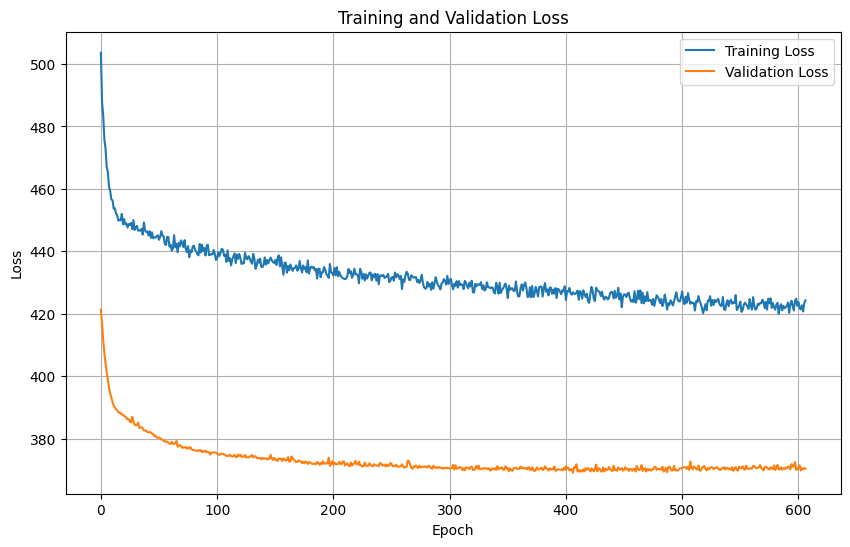

In [110]:
# Evaluation with both models
def evaluate(model, loader):
    model.eval()
    losses = []
    with torch.no_grad():
        for lr, hr in loader:
            lr, hr = lr.to(device), hr.to(device)
            pred_s, pred_yl, pred_yh, pred = model(lr)

            hr_yl, hr_yh = dwt(hr)
            hr_yh = hr_yh[0]
            # Main reconstruction loss
            recon_loss = criterion(pred, hr)
            # Spatial domain loss
            spatial_loss = criterion(pred_s, hr)
            # Losses on low- and high-frequency components
            low_freq_loss  = criterion(pred_yl, hr_yl)
            high_freq_loss  = criterion(pred_yh, hr_yh)
            # Weighted combination
            loss =  lamda_reconstruction * recon_loss + lamda_spatial * spatial_loss + lamda_low_freq * low_freq_loss + lamda_high_freq * high_freq_loss


            losses.append(loss.item())
    return np.mean(losses)

# Initialize early stopping variables
best_val_loss = float('inf')
counter = 0
best_epoch = 0
train_losses, val_losses = [], []

# Training epochs
for epoch in range(num_epochs):
    model.train()
    batch_losses = []

    for lr, hr in train_loader:
        lr, hr = lr.to(device), hr.to(device)
        optimizer.zero_grad()
        pred_s, pred_yl, pred_yh, pred = model(lr)

        # Decompose ground truth HR image
        hr_yl, hr_yh = dwt(hr)
        hr_yh = hr_yh[0]
        # Main reconstruction loss
        recon_loss = criterion(pred, hr)
        # Spatial domain loss
        spatial_loss = criterion(pred_s, hr)
        # Losses on low- and high-frequency components
        low_freq_loss  = criterion(pred_yl, hr_yl)
        high_freq_loss  = criterion(pred_yh, hr_yh)
        # Weighted combination
        loss =  lamda_reconstruction * recon_loss + lamda_spatial * spatial_loss + lamda_low_freq * low_freq_loss + lamda_high_freq * high_freq_loss

        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)
    val_loss = evaluate(model, val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 20 == 0:
      print(f"Epoch {epoch+1}: Train Loss={train_loss:.5f}, Val Loss={val_loss:.5f}, Learning Rate = {optimizer.param_groups[0]['lr']}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = model.state_dict()
        best_epoch = epoch
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping!")
            print(f"Epoch {epoch+1}: Train Loss={train_loss:.5f}, Val Loss={val_loss:.5f}")
            print(f"Best epoch: {best_epoch+1}, Best val loss: {best_val_loss:.5f}")
            break

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Evaluation

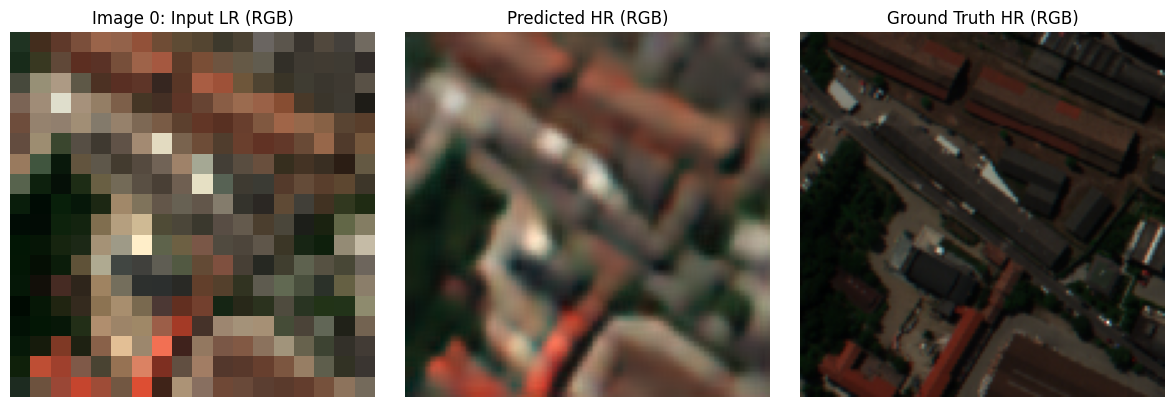

Num test images: 1
Average PSNR: 25.575644
Average SSIM: 0.5847809
Average SAM: 7.6276436
Average CC: 0.8347046692635114
Average ERGAS: 4.498083
Average RMSE: 0.053652626


In [111]:
# Load the best performing model weights
model.load_state_dict(best_model_wts)
model.eval()

# --- Accumulators over ALL test images ---
psnr_values, ssim_values, cc_values, sam_values, ergas_values, rmse_values = [], [], [], [], [], []

# Iterators over loaders
hr_iter = iter(test_loader_hr)
lr_iter = iter(test_loader_lr)

num_groups = len(group_indices) if use_band_grouping else 1
image_idx = 0

with torch.no_grad():
    while True:
        # 1) Gather LR groups for ONE image
        pred_list = []
        lr_list = []
        got_any_group = False

        for g in range(num_groups):
            try:
                lr_temp = next(lr_iter)  # expects shape (1, Cg, H, W)
            except StopIteration:
                # If we never got any group for a new image, we are done
                if not got_any_group:
                    lr_temp = None
                break

            got_any_group = True
            lr_temp = lr_temp.to(device)

            # Make prediction for this group
            _, _, _, pred_temp = model(lr_temp)

            # To numpy (C,H,W)
            pred_np = pred_temp.squeeze(0).detach().cpu().numpy()
            lr_np   = lr_temp.squeeze(0).detach().cpu().numpy()

            pred_list.append(pred_np)
            lr_list.append(lr_np)

        if not got_any_group:
            # No more images
            break

        # 2) Reconstruct full spectral cube from groups
        pred_combined, lr_combined = combine_groups(pred_list, lr_list, use_band_grouping, group_indices)

        # 3) Get the corresponding HR image
        hr = next(hr_iter)  # expects shape (1, C_hr, H, W)
        hr = hr.to(device).squeeze(0).cpu().numpy()  # (C_hr, H, W)

        # 4) Align channel counts (truncate preds/inputs if padding was used)
        total_predicted_bands = pred_combined.shape[0]
        c_hr = hr.shape[0]
        c = min(total_predicted_bands, c_hr)

        pred = pred_combined[:c, :, :]
        lr   = lr_combined[:c, :, :]
        hr   = hr[:c, :, :]

        # 5) Compute metrics for THIS image
        psnr_values.append(psnr(hr, pred))
        ssim_values.append(ssim_value(hr, pred))
        cc_values.append(correlation_coefficient(hr, pred))
        sam_values.append(sam(hr, pred))
        ergas_values.append(ergas(hr, pred, downscale_factor))
        rmse_values.append(rmse_bandwise(hr, pred))


        # 6) Plot RGB composites per image

        rgb_lr   = get_rgb_image(lr)
        rgb_pred = get_rgb_image(pred)
        rgb_hr   = get_rgb_image(hr)

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(rgb_lr)
        plt.title(f"Image {image_idx}: Input LR (RGB)")
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(rgb_pred) 
        plt.title("Predicted HR (RGB)")              
        plt.axis('off')

        plt.subplot(1, 3, 3) 
        plt.imshow(rgb_hr)  
        plt.title("Ground Truth HR (RGB)")            
        plt.axis('off')

        plt.tight_layout()
        plt.show()

        image_idx += 1

# --- Print aggregate metrics across ALL images ---
print("Num test images:", image_idx)
print("Average PSNR:",  np.mean(psnr_values))
print("Average SSIM:",  np.mean(ssim_values))
print("Average SAM:",   np.mean(sam_values))
print("Average CC:",    np.mean(cc_values))
print("Average ERGAS:", np.mean(ergas_values))
print("Average RMSE:",  np.mean(rmse_values))
